<a href="https://colab.research.google.com/github/AlexandreLouzada/exercicios-analise-dados/blob/master/analise_visual_vendas_GABARITO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Exercício Prático: Análise Visual de Vendas com Pandas e Matplotlib — GABARITO

**Objetivo:** Ler um conjunto de dados, realizar manipulações básicas com Pandas e criar visualizações claras usando Matplotlib para responder a perguntas de negócios.

**Como usar no Google Colab:**
1. Acesse [colab.research.google.com](https://colab.research.google.com)
2. Clique em `Arquivo > Fazer upload do notebook` e selecione este arquivo `.ipynb`
3. Execute as células em ordem com `Shift + Enter` (ou `Executar tudo` em `Tempo de execução`)
4. Não é preciso instalar nada: `pandas`, `matplotlib` e `numpy` já vêm no Colab.

---

## 🧱 Bloco 1: Preparação do Ambiente e Dados

A célula abaixo cria um dataset fictício de 300 vendas entre 01/01/2024 e 30/06/2024, com 4 produtos. Execute-a primeiro.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Criação de um dataset fictício de vendas
np.random.seed(42)
datas = pd.date_range(start="2024-01-01", end="2024-06-30", freq="D")
produtos = ["Notebook", "Smartphone", "Fone de Ouvido", "Monitor"]

dados = {
    "Data": np.random.choice(datas, size=300),
    "Produto": np.random.choice(produtos, size=300, p=[0.2, 0.4, 0.25, 0.15]),
    "Quantidade": np.random.randint(1, 6, size=300),
    "Preco_Unitario": 0
}

df = pd.DataFrame(dados)

# Atribuindo preços de acordo com o produto
precos = {"Notebook": 3500, "Smartphone": 2000, "Fone de Ouvido": 150, "Monitor": 1200}
df["Preco_Unitario"] = df["Produto"].map(precos)

print("Dataset criado com sucesso! Primeiras linhas:")
df.head()

Dataset criado com sucesso! Primeiras linhas:


,Data,Produto,Quantidade,Preco_Unitario
0,2024-04-12,Monitor,3,1200
1,2024-06-28,Smartphone,1,2000
2,2024-04-02,Monitor,5,1200
3,2024-01-15,Fone de Ouvido,4,150
4,2024-04-16,Fone de Ouvido,1,150


### 🔍 Exploração rápida (opcional, mas recomendado)

Antes de responder às tarefas, vamos entender o dataset:

In [2]:
# Visão geral do dataset
print("Dimensões (linhas, colunas):", df.shape)
print()
print(df.info())
print()
print("Estatísticas descritivas:")
display(df.describe(include='all'))
print()
print("Contagem por produto:")
print(df["Produto"].value_counts())

Dimensões (linhas, colunas): (300, 4)

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Data            300 non-null    datetime64[us]
 1   Produto         300 non-null    str           
 2   Quantidade      300 non-null    int32         
 3   Preco_Unitario  300 non-null    int64         
dtypes: datetime64[us](1), int32(1), int64(1), str(1)
memory usage: 11.3 KB
None

Estatísticas descritivas:


,Data,Produto,Quantidade,Preco_Unitario
count,300,300,300.00000,300.000000
unique,NaN,4,NaN,NaN
top,NaN,Smartphone,NaN,NaN
freq,NaN,102,NaN,NaN
mean,2024-04-03 17:45:36,NaN,2.96000,1704.333333
min,2024-01-01 00:00:00,NaN,1.00000,150.000000
25%,2024-02-20 18:00:00,NaN,2.00000,150.000000
50%,2024-04-08 00:00:00,NaN,3.00000,2000.000000
75%,2024-05-15 00:00:00,NaN,4.00000,2000.000000
max,2024-06-28 00:00:00,NaN,5.00000,3500.000000



Contagem por produto:
Produto
Smartphone        102
Fone de Ouvido     76
Notebook           65
Monitor            57
Name: count, dtype: int64


## ✅ Tarefa 1: Faturamento por Produto

**Pergunta de negócio:** Qual produto gera mais receita para a empresa?

**Passos:**
1. Crie uma nova coluna chamada `Faturamento_Total` calculando `Quantidade × Preco_Unitario`.
2. Agrupe os dados por `Produto` e calcule a soma do faturamento de cada um.
3. Gere um gráfico de barras com título, rótulos nos eixos X e Y e cores personalizadas.

In [3]:
# 1. Criar a coluna Faturamento_Total
df["Faturamento_Total"] = df["Quantidade"] * df["Preco_Unitario"]

# 2. Agrupar por Produto e somar o faturamento
faturamento_por_produto = df.groupby("Produto")["Faturamento_Total"].sum().sort_values(ascending=False)

print("Faturamento total por produto:")
print(faturamento_por_produto)
print(f"\nFaturamento geral: R$ {faturamento_por_produto.sum():,.2f}")

Faturamento total por produto:
Produto
Notebook          686000
Smartphone        626000
Monitor           213600
Fone de Ouvido     30150
Name: Faturamento_Total, dtype: int64

Faturamento geral: R$ 1,555,750.00


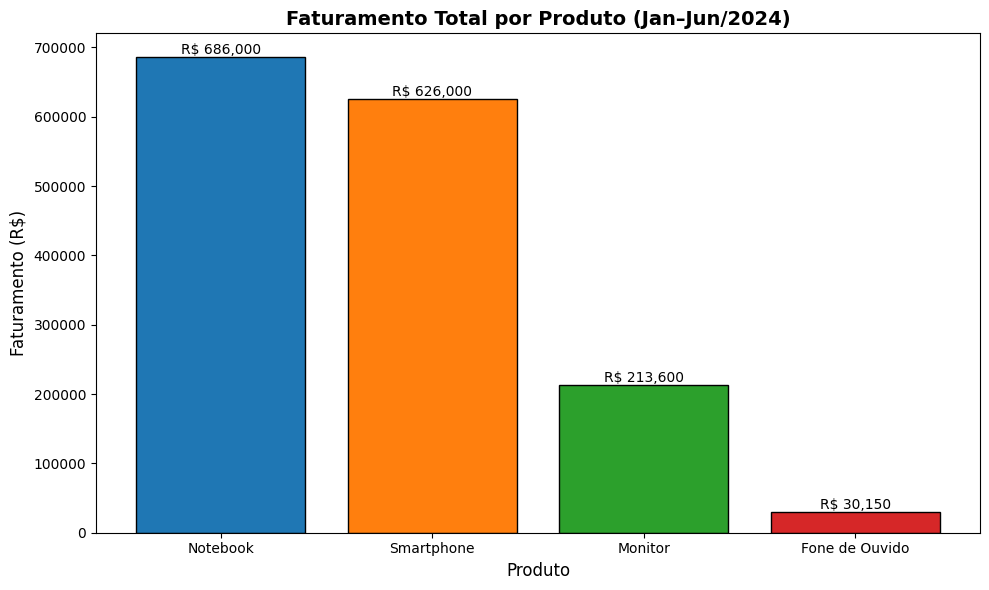

In [4]:
# 3. Gráfico de barras — Faturamento por Produto
plt.figure(figsize=(10, 6))
cores = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]  # azul, laranja, verde, vermelho
barras = plt.bar(faturamento_por_produto.index, faturamento_por_produto.values, color=cores, edgecolor="black")

plt.title("Faturamento Total por Produto (Jan–Jun/2024)", fontsize=14, fontweight="bold")
plt.xlabel("Produto", fontsize=12)
plt.ylabel("Faturamento (R$)", fontsize=12)
plt.xticks(rotation=0)

# Rótulos de valor no topo de cada barra
for barra in barras:
    altura = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2, altura,
             f"R$ {altura:,.0f}", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

# 💡 Resposta: o Smartphone lidera (maior volume + preço alto), seguido pelo Notebook.

## ✅ Tarefa 2: Evolução das Vendas ao Longo do Tempo

**Pergunta de negócio:** As vendas estão crescendo, caindo ou estáveis mês a mês?

**Passos:**
1. Crie a coluna `Mes` extraindo o mês da coluna `Data`.
2. Agrupe por mês e some o faturamento.
3. Gere um gráfico de linha com marcadores, título e rótulos de eixos.

In [5]:
# 1. Criar a coluna Mes (formato Ano-Mês para ordenação correta)
df["Mes"] = df["Data"].dt.to_period("M").astype(str)  # ex: '2024-01'
# Alternativa equivalente: df["Mes_num"] = df["Data"].dt.month

# 2. Agrupar por mês e somar o faturamento
faturamento_mensal = df.groupby("Mes")["Faturamento_Total"].sum().sort_index()

print("Faturamento por mês:")
print(faturamento_mensal)

Faturamento por mês:
Mes
2024-01    210300
2024-02    235950
2024-03    278450
2024-04    247650
2024-05    379650
2024-06    203750
Name: Faturamento_Total, dtype: int64


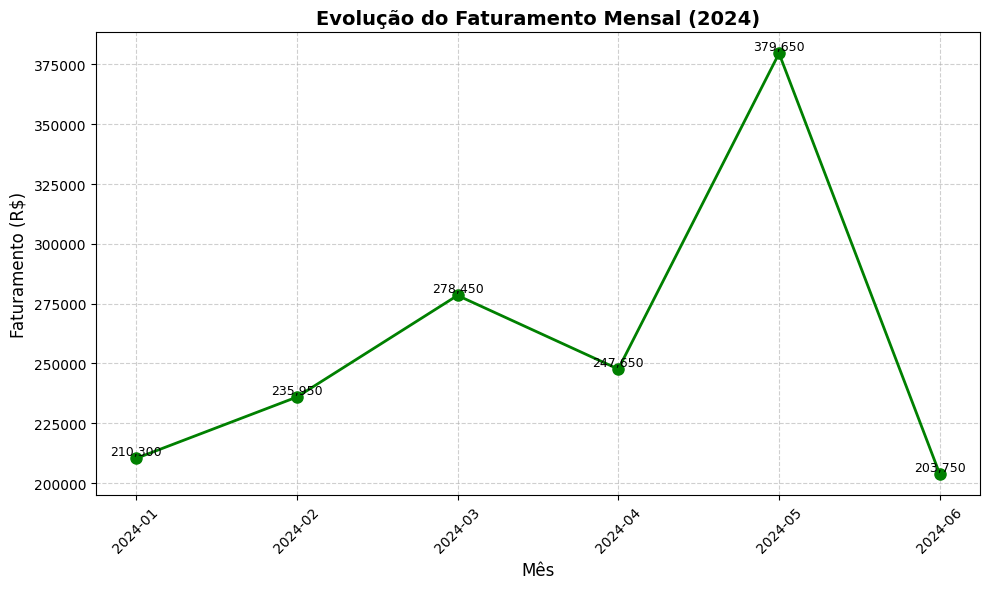

In [6]:
# 3. Gráfico de linha — Evolução mensal
plt.figure(figsize=(10, 6))
plt.plot(faturamento_mensal.index, faturamento_mensal.values,
         marker="o", markersize=8, linewidth=2, color="green")

plt.title("Evolução do Faturamento Mensal (2024)", fontsize=14, fontweight="bold")
plt.xlabel("Mês", fontsize=12)
plt.ylabel("Faturamento (R$)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.xticks(rotation=45)

# Rótulos de valor em cada ponto
for x, y in zip(faturamento_mensal.index, faturamento_mensal.values):
    plt.text(x, y, f"{y:,.0f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

## ✅ Tarefa 3: Distribuição da Quantidade Vendida

**Pergunta de negócio:** Qual a participação de cada produto no total de unidades vendidas?

**Passos:**
1. Some a `Quantidade` por `Produto`.
2. Crie um gráfico de pizza com as porcentagens em cada fatia.

In [7]:
# 1. Somar a quantidade vendida por produto
qtd_por_produto = df.groupby("Produto")["Quantidade"].sum().sort_values(ascending=False)

print("Unidades vendidas por produto:")
print(qtd_por_produto)
print(f"\nTotal de unidades: {qtd_por_produto.sum()}")

Unidades vendidas por produto:
Produto
Smartphone        313
Fone de Ouvido    201
Notebook          196
Monitor           178
Name: Quantidade, dtype: int32

Total de unidades: 888


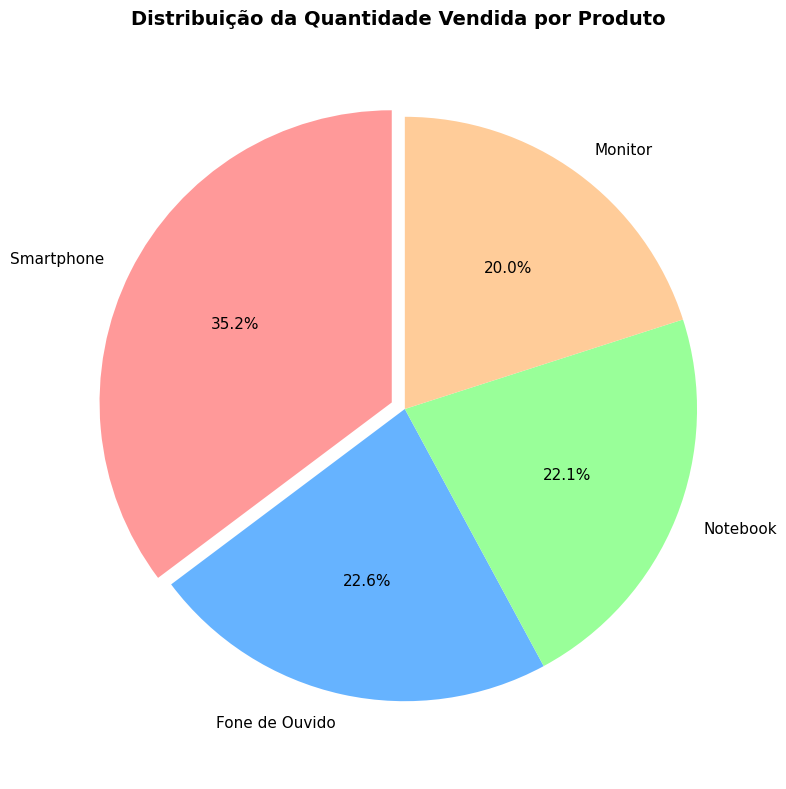

In [8]:
# 2. Gráfico de pizza — Proporção de itens vendidos
plt.figure(figsize=(8, 8))
cores_pizza = ["#ff9999", "#66b3ff", "#99ff99", "#ffcc99"]
explode = [0.05 if v == qtd_por_produto.max() else 0 for v in qtd_por_produto.values]  # destaca a maior fatia

plt.pie(qtd_por_produto.values,
        labels=qtd_por_produto.index,
        autopct="%1.1f%%",   # exibe porcentagens
        startangle=90,
        colors=cores_pizza,
        explode=explode,
        shadow=False,
        textprops={"fontsize": 11})

plt.title("Distribuição da Quantidade Vendida por Produto", fontsize=14, fontweight="bold")
plt.axis("equal")  # garante pizza circular
plt.tight_layout()
plt.show()

# 💡 Resposta: o Smartphone concentra ~40% das unidades (probabilidade 0.4 no sorteio),
# mas note que faturamento ≠ unidades: o Fone é barato e vende muito em volume, porém fatura pouco.

## 🎓 Conclusão — Respostas executivas

Execute a célula abaixo para ver o resumo pronto para apresentar à diretoria:

In [9]:
print("=" * 60)
print("RELATÓRIO EXECUTIVO — Vendas Jan-Jun/2024")
print("=" * 60)
print(f"1️⃣ Maior faturamento: {faturamento_por_produto.idxmax()} (R$ {faturamento_por_produto.max():,.2f})")
print(f"2️⃣ Melhor mês: {faturamento_mensal.idxmax()} (R$ {faturamento_mensal.max():,.2f})")
print(f"   Pior mês:  {faturamento_mensal.idxmin()} (R$ {faturamento_mensal.min():,.2f})")
print(f"3️⃣ Produto mais vendido em UNIDADES: {qtd_por_produto.idxmax()} ({qtd_por_produto.max()} un.)")
print(f"   Ticket médio por venda: R$ {df['Faturamento_Total'].mean():,.2f}")
print("=" * 60)

RELATÓRIO EXECUTIVO — Vendas Jan-Jun/2024
1️⃣ Maior faturamento: Notebook (R$ 686,000.00)
2️⃣ Melhor mês: 2024-05 (R$ 379,650.00)
   Pior mês:  2024-06 (R$ 203,750.00)
3️⃣ Produto mais vendido em UNIDADES: Smartphone (313 un.)
   Ticket médio por venda: R$ 5,185.83


### 🚀 Desafio extra (opcional)

1. Qual o ticket médio por produto? (dica: `df.groupby("Produto")["Faturamento_Total"].mean()`)
2. Qual dia da semana vende mais? (dica: `df["Data"].dt.day_name()`)
3. Salve os gráficos com `plt.savefig("grafico.png", dpi=300)` e insira no relatório.

Bom estudo! 🎉